# California Housing – Regression

## Mål
Målet med uppgiften är att bygga en modell som kan förutsäga `median_house_value`, alltså ungefär vad bostäder är värda i olika områden i Kalifornien.

## Problemtyp
Detta är ett regressionsproblem eftersom vi försöker förutsäga ett numeriskt värde, inte en klass.

## Syfte
Tanken är att modellen ska kunna användas som ett enkelt beslutsstöd, till exempel för att få en ungefärlig bild av vilka områden som är dyrare eller billigare.

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


from sklearn.linear_model import LinearRegression, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Dataförståelse och EDA

Datasetet innehåller information om olika områden i Kalifornien, till exempel geografi, antal hushåll, inkomst och närhet till hav.
Här undersöker vi datan för att få en bättre bild av hur den ser ut innan vi börjar modellera.

In [40]:
print("Datasetstorlek:", df.shape)


num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object", "string"]).columns

print("\nSammanfattning:")
print(f"Antal rader: {df.shape[0]}")
print(f"Antal kolumner: {df.shape[1]}")
print(f"Numeriska variabler: {len(num_cols)}")
print(f"Kategoriska variabler: {len(cat_cols)}")
print("\nTarget-variabel:", "median_house_value")



Datasetstorlek: (20640, 10)

Sammanfattning:
Antal rader: 20640
Antal kolumner: 10
Numeriska variabler: 9
Kategoriska variabler: 1

Target-variabel: median_house_value


### Saknade värden

In [55]:
missing = df.isna().sum()
missing = missing[missing > 0]

print("\nSaknade värden:")
if len(missing) > 0:
    print(missing)
else:
    print("Inga saknade värden")


Saknade värden:
total_bedrooms       207
bedrooms_per_room    207
dtype: int64


Det finns bara saknade värden i kolumnen `total_bedrooms`, totalt 207 stycken.
Eftersom det är en ganska liten del av datan väljer vi att inte ta bort rader, utan istället fylla i dessa värden senare i preprocessing-steget.

## Fördelning av target

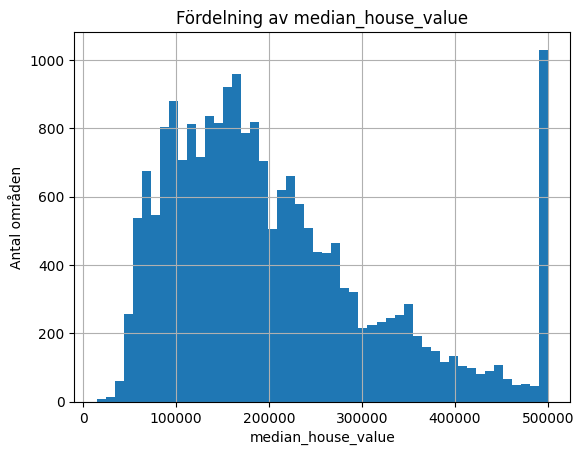

In [42]:
plt.figure()
df["median_house_value"].hist(bins=50)
plt.title("Fördelning av median_house_value")
plt.xlabel("median_house_value")
plt.ylabel("Antal områden")
plt.show()

Histogrammet visar att bostadsvärdena inte är jämnt fördelade. Det finns fler områden med lägre värden och färre med väldigt höga värden.
Man kan också se att det finns ett tak i datan, vilket gör att de högsta värdena klumpas ihop.

## Geografiska mönster

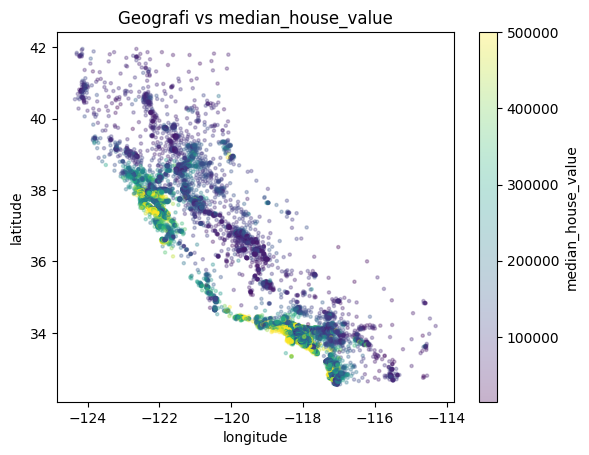

In [43]:
plt.figure()
plt.scatter(df["longitude"], df["latitude"], s=5, alpha=0.3, c=df["median_house_value"])
plt.title("Geografi vs median_house_value")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.colorbar(label="median_house_value")
plt.show()

När vi plotterar data på en karta ser vi tydligt att läget spelar stor roll.
Områden nära kusten verkar ha högre bostadsvärden än områden längre in i landet.

## Feature engineering

Vissa variabler är totalsummor per område, så vi skapar nya variabler som ger mer information per hushåll.

Till exempel:
- rum per hushåll
- sovrum per rum
- personer per hushåll

Detta kan hjälpa modellen att förstå datan bättre.

In [44]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

### Definiera target & features

In [45]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

## Train/test-split

Datan delas upp i träningsdata och testdata.
Träningsdatan används för att bygga modellen, och testdatan används för att se hur bra modellen fungerar på ny data.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Dela upp numeriska & kategoriska features

In [47]:
num_features = X.select_dtypes(include=["float64"]).columns
cat_features = X.select_dtypes(include=["object"]).columns

C:\Users\almav\AppData\Local\Temp\ipykernel_22400\2894318808.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include=["object"]).columns


## Preprocessing

För att hantera datan på ett korrekt sätt använder vi en pipeline.

Numeriska variabler:
- saknade värden fylls med median
- värdena skalas

Kategoriska variabler:
- saknade värden fylls med vanligaste värdet
- omvandlas till siffror med OneHotEncoding

Detta gör att samma steg används både vid träning och test.

In [48]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

## Modellering – val av modeller

Vi testar flera modeller för att se vilken som fungerar bäst:

- Baseline (DummyRegressor)
- Linear Regression
- Random Forest

Eftersom detta är ett regressionsproblem använder vi RMSE och R² för att jämföra modellerna.

In [49]:
baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

linreg = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

### Utvärdering

Vi använder två mått:

- RMSE: visar ungefär hur mycket modellen har fel i sina prediktioner
- R²: visar hur bra modellen förklarar variationen i datan

RMSE är lätt att tolka eftersom det är i samma enhet som bostadspriserna.

In [50]:
def evaluate(model, X_test, y_test):
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    return rmse, r2

## Träna och jämföra modeller

In [51]:
models = {
    "Baseline": baseline,
    "LinearRegression": linreg,
    "RandomForest": rf
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    rmse, r2 = evaluate(model, X_test, y_test)
    
    results.append({
        "model": name,
        "RMSE": rmse,
        "R2": r2
    })

pd.DataFrame(results)

,model,RMSE,R2
0,Baseline,114485.635431,-0.000219
1,LinearRegression,69127.038299,0.635339
2,RandomForest,49833.732394,0.810487


### Val av slutmodell

Random Forest valdes som slutmodell. Den har både lägst RMSE och högst R², vilket innebär att den gör minst prediktionsfel och förklarar störst del av variationen i bostadsvärdena.

## Cross-validation

För att få en mer stabil utvärdering testar vi modellen flera gånger på olika delar av datan.
Resultatet ligger nära testresultatet, vilket tyder på att modellen fungerar ganska bra även på ny data.

In [ ]:
scores = cross_val_score(
    rf,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=5
)

Cross-validation genomfördes på Random Forest (slutmodellen)

## Hyperparameter tuning

Vi testar några olika inställningar för Random Forest för att se om vi kan förbättra modellen.
Den bästa modellen använder 100 träd och ingen begränsning på djupet.

In [53]:
param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [None, 10, 20]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error"
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'model__max_depth': None, 'model__n_estimators': 100}


## Slutsats

Modellen kan användas för att göra ungefärliga uppskattningar av bostadsvärden i olika områden.
Den fångar viktiga mönster i datan, särskilt kopplade till inkomst och geografiskt läge.

### Rekommendation

Modellen kan användas som ett beslutsstöd för att uppskatta bostadsvärden på områdesnivå. 
Den är särskilt användbar för att identifiera områden med högt eller lågt värde inför investeringar.

Dock bör modellen inte användas för exakta värderingar av enskilda bostäder.

## Risker och begränsningar

- Datan är aggregerad per område, inte per bostad  
- Saknade värden hanteras med imputering, ger viss osäkerhet  
- Modellen fångar samband, inte orsakssamband  
- Geografiska mönster kan påverka modellen starkt  